<a href="https://colab.research.google.com/github/Tungtom2004/Mining_massive_data_N6/blob/main/feature-engineering-and-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
    "pyarrow", "pandas", "scikit-learn", "umap-learn", "matplotlib", "seaborn",
    "huggingface_hub", "tqdm"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--upgrade', 'pyarrow', 'pandas', 'scikit-learn', 'umap-learn', 'matplotlib', 'seaborn', 'huggingface_hub', 'tqdm'], returncode=0)

In [10]:
import pandas as pd
import numpy as np
import os

def extract_features(parquet_path):
    cols = [
        "channel_name","date","views","forwards","replies","forward",
        "photo","video","voice","web_preview","buttons","other_media",
        "content","urls","hashtags",
        "toxicity","severe_toxicity","identity_attack","insult","profanity","threat",
        "political","language","chain_from_id"
    ]

    df = pd.read_parquet(parquet_path, columns=cols)

    if len(df) == 0:
        return None

    channel_name = df["channel_name"].iloc[0] if "channel_name" in df.columns else os.path.basename(parquet_path).replace(".parquet", "")

    df["_ts"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[df["_ts"].notna()]   # ❌ bỏ .copy()

    if len(df) < 5:
        return None

    # 👉 dùng numpy thay vì pandas dt (nhẹ hơn chút)
    ts = df["_ts"]
    df["_hour"] = ts.dt.hour
    df["_dow"] = ts.dt.dayofweek
    df["_date"] = ts.dt.date

    n = len(df)
    active_days = df["_date"].nunique()
    date_span = max((ts.max() - ts.min()).days, 1)

    daily_counts = df.groupby("_date").size()
    burst = daily_counts.std() / daily_counts.mean() if daily_counts.mean() > 0 else 0

    # 🔥 tối ưu word count (tránh split full list)
    content = df["content"].fillna("")
    content_lens = content.str.count(r"\S+")

    frac = lambda cond: cond.mean()

    views_mean = df["views"].mean()

    return {
        "channel_name": channel_name,

        "total_messages": n,
        "active_days": active_days,
        "msgs_per_day": n / date_span,
        "burstiness": burst,
        "frac_night": frac((df["_hour"] < 6)),
        "frac_morning": frac((df["_hour"] >= 6) & (df["_hour"] < 12)),
        "frac_afternoon": frac((df["_hour"] >= 12) & (df["_hour"] < 18)),
        "frac_evening": frac((df["_hour"] >= 18)),
        "frac_weekend": frac(df["_dow"].isin([5, 6])),

        "avg_views": views_mean,
        "median_views": df["views"].median(),
        "max_views": df["views"].max(),
        "avg_forwards": df["forwards"].mean(),
        "forward_ratio": frac(df["forwards"] > 0),
        "avg_replies": df["replies"].mean(),
        "reply_ratio": frac(df["replies"] > 0),
        "frac_is_forward": frac(df["forward"] > 0),
        "fwd_per_view": df["forwards"].mean() / max(views_mean, 1),
        "reply_per_view": df["replies"].mean() / max(views_mean, 1),

        "avg_word_count": content_lens.mean(),
        "frac_photo": frac(df["photo"] > 0),
        "frac_video": frac(df["video"] > 0),
        "frac_voice": frac(df["voice"] > 0),
        "frac_web_preview": frac(df["web_preview"] > 0),
        "frac_buttons": frac(df["buttons"] > 0),

        "frac_text_only": frac(
            (df["photo"] == 0) & (df["video"] == 0) &
            (df["voice"] == 0) & (df["other_media"] == 0) &
            (content.str.len() > 0)
        ),

        "frac_has_urls": frac(df["urls"].fillna("").str.len() > 2),
        "frac_has_hashtags": frac(df["hashtags"].fillna("").str.len() > 2),

        "avg_toxicity": df["toxicity"].mean(),
        "avg_severe_toxicity": df["severe_toxicity"].mean(),
        "avg_identity_attack": df["identity_attack"].mean(),
        "avg_insult": df["insult"].mean(),
        "avg_profanity": df["profanity"].mean(),
        "avg_threat": df["threat"].mean(),
        "avg_political": pd.to_numeric(df["political"], errors="coerce").mean(),
        "frac_high_toxic": frac(df["toxicity"] > 0.5),

        "n_languages": df["language"].nunique(),
        "n_fwd_sources": df["chain_from_id"].fillna("").str.strip().replace("", pd.NA).dropna().nunique(),
        "frac_chain": frac(df["chain_from_id"].fillna("").str.len() > 0),
    }

In [3]:
import os, shutil
import pandas as pd
import numpy as np
from glob import glob
from tqdm import tqdm
from huggingface_hub import hf_hub_download

REPO_ID = "Tungtom2004/Telegram_politic_dataset"
CHANNEL_RANGE = range(10, 13)

rows = []
errors = []

for i in CHANNEL_RANGE:
    zip_name = f"channels_{i}_parquet.zip"
    raw_dir = f"./channels_{i}_parquet"

    print(f"\n{'='*50}")
    print(f"Processing channels_{i}")

    try:
        local_zip = hf_hub_download(
            repo_id=REPO_ID, filename=zip_name,
            repo_type="dataset", revision="main"
        )
        os.system(f"unzip -q '{local_zip}' -d .")
    except Exception as e:
        print(f"FAIL download: {e}")
        continue

    parquet_files = sorted(glob(f"{raw_dir}/*.parquet"))
    print(f"  {len(parquet_files)} files")

    for pf in tqdm(parquet_files, desc=f"ch_{i}", leave=False):
        try:
            feat = extract_features(pf)
            if feat is not None:
                rows.append(feat)
        except Exception as e:
            errors.append((os.path.basename(pf), str(e)))

    shutil.rmtree(raw_dir, ignore_errors=True)

    cache = os.path.expanduser("~/.cache/huggingface")
    if os.path.exists(cache):
        shutil.rmtree(cache, ignore_errors=True)

    print(f"  Done. Channels so far: {len(rows)} | Errors: {len(errors)}")

df_profiles = pd.DataFrame(rows)
print(f"\nTotal channels: {len(df_profiles)}")
print(f"Total errors: {len(errors)}")


Processing channels_10


channels_10_parquet.zip:   0%|          | 0.00/1.93G [00:00<?, ?B/s]

  0 files


  Done. Channels so far: 0 | Errors: 0

Processing channels_11


channels_11_parquet.zip:   0%|          | 0.00/6.08G [00:00<?, ?B/s]

  0 files


  Done. Channels so far: 0 | Errors: 0

Processing channels_12


channels_12_parquet.zip:   0%|          | 0.00/8.10G [00:00<?, ?B/s]

  0 files


  Done. Channels so far: 0 | Errors: 0

Total channels: 0
Total errors: 0


In [5]:
import os

for i in CHANNEL_RANGE:
    path = f"./channels_{i}_parquet"
    print(path, os.path.exists(path))

./channels_10_parquet False
./channels_11_parquet False
./channels_12_parquet False


In [2]:
CHANNEL_RANGE = range(10, 13)

In [7]:
import pandas as pd
import numpy as np
import os, shutil
import pandas as pd
import numpy as np
from glob import glob
from tqdm import tqdm
from huggingface_hub import hf_hub_download

In [11]:
from glob import glob
from tqdm import tqdm

all_parquets = []
for i in CHANNEL_RANGE:
    all_parquets += sorted(glob(f"./kaggle/working/channels_{i}_parquet/*.parquet"))

print(f"Total parquet files: {len(all_parquets)}")

rows = []
errors = []

for pf in tqdm(all_parquets, desc="Extracting features"):
    try:
        feat = extract_features(pf)
        if feat is not None:
            rows.append(feat)
    except Exception as e:
        errors.append((pf, str(e)))

df_profiles = pd.DataFrame(rows)

print(f"Channels with features: {len(df_profiles)}")
print(f"Errors: {len(errors)}")
if errors:
    for path, err in errors[:5]:
        print(f"  {os.path.basename(path)}: {err}")

Total parquet files: 6431


Extracting features: 100%|██████████| 6431/6431 [45:27<00:00,  2.36it/s]


Channels with features: 6369
Errors: 0


In [12]:
df_profiles = df_profiles[
    (df_profiles["total_messages"] >= 10) &
    (df_profiles["active_days"] >= 3)
].copy()

df_profiles = df_profiles.fillna(0)
df_profiles.to_csv("channel_profiles.csv", index=False)

print(f"Final: {len(df_profiles)} channels")
print(f"Columns: {len(df_profiles.columns)}")
df_profiles.describe().round(2)

Final: 6303 channels
Columns: 40


,total_messages,active_days,msgs_per_day,burstiness,frac_night,frac_morning,frac_afternoon,frac_evening,frac_weekend,avg_views,...,avg_severe_toxicity,avg_identity_attack,avg_insult,avg_profanity,avg_threat,avg_political,frac_high_toxic,n_languages,n_fwd_sources,frac_chain
count,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,...,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00,6303.00
mean,27595.68,266.63,264.52,0.73,0.13,0.29,0.34,0.24,0.25,16447.69,...,0.00,0.01,0.01,0.01,0.01,0.14,0.00,14.48,95.78,0.16
std,108252.54,135.73,2256.40,0.45,0.12,0.16,0.12,0.15,0.08,146550.20,...,0.01,0.02,0.02,0.02,0.01,0.22,0.02,12.62,263.41,0.23
min,10.00,3.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,512.00,147.50,1.36,0.47,0.03,0.18,0.28,0.13,0.22,454.41,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,3.00,0.01
50%,2051.00,311.00,5.56,0.67,0.09,0.29,0.34,0.23,0.26,1911.60,...,0.00,0.00,0.00,0.00,0.00,0.02,0.00,9.00,14.00,0.05
75%,9646.50,392.00,26.24,0.88,0.20,0.39,0.40,0.33,0.29,6878.04,...,0.00,0.00,0.01,0.02,0.01,0.22,0.00,24.00,72.00,0.21
max,1222736.00,451.00,83097.00,10.89,1.00,1.00,1.00,1.00,1.00,8985087.79,...,0.17,0.36,0.26,0.36,0.16,1.00,0.31,55.00,5855.00,1.00


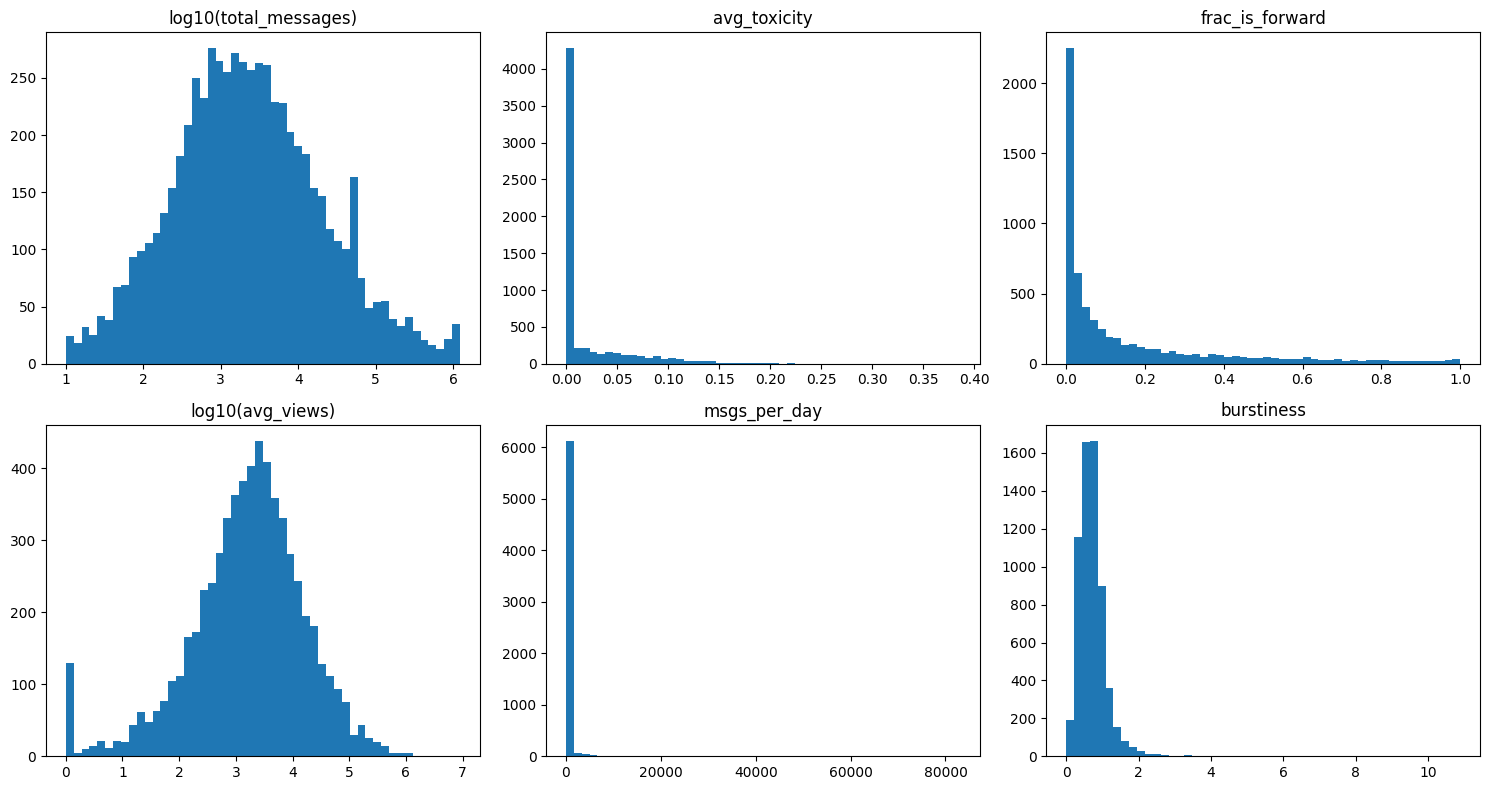

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(np.log10(df_profiles["total_messages"].clip(1)), bins=50)
axes[0,0].set_title("log10(total_messages)")

axes[0,1].hist(df_profiles["avg_toxicity"], bins=50)
axes[0,1].set_title("avg_toxicity")

axes[0,2].hist(df_profiles["frac_is_forward"], bins=50)
axes[0,2].set_title("frac_is_forward")

axes[1,0].hist(np.log10(df_profiles["avg_views"].clip(1)), bins=50)
axes[1,0].set_title("log10(avg_views)")

axes[1,1].hist(df_profiles["msgs_per_day"], bins=50)
axes[1,1].set_title("msgs_per_day")

axes[1,2].hist(df_profiles["burstiness"], bins=50)
axes[1,2].set_title("burstiness")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import RobustScaler

feature_cols = [c for c in df_profiles.columns if c != "channel_name"]

X = df_profiles[feature_cols].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix: {X_scaled.shape}")

Feature matrix: (6303, 39)


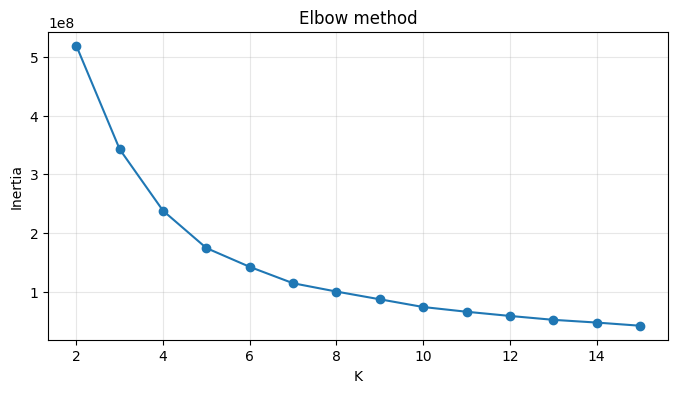

In [15]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, "o-")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
K = 5

km = KMeans(n_clusters=K, n_init=20, random_state=42, max_iter=500)
df_profiles["cluster"] = km.fit_predict(X_scaled)

print(df_profiles["cluster"].value_counts().sort_index())

cluster
0    6224
1      22
2       1
3      55
4       1
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


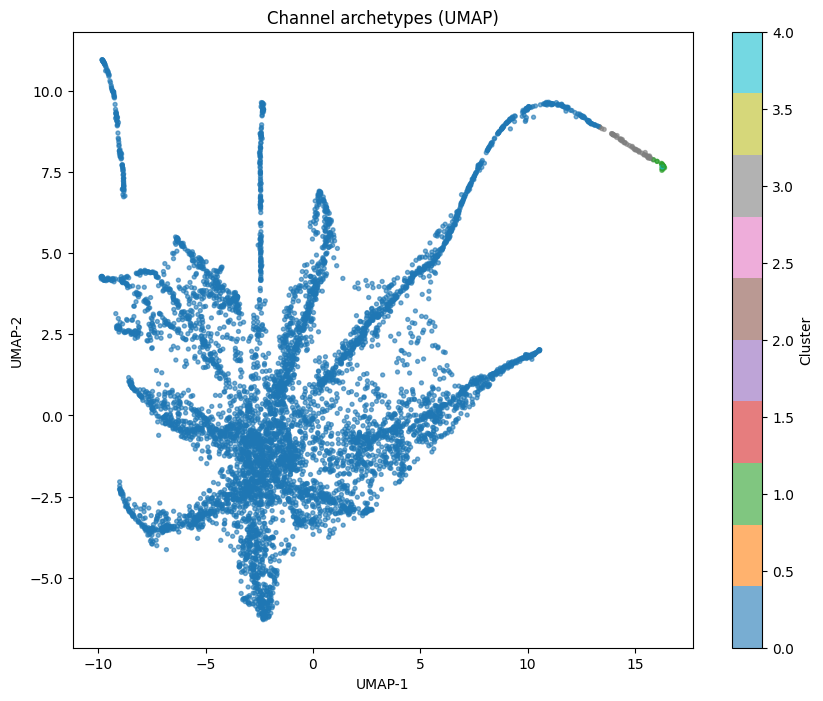

In [17]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
embedding = reducer.fit_transform(X_scaled)

df_profiles["umap_x"] = embedding[:, 0]
df_profiles["umap_y"] = embedding[:, 1]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_profiles["umap_x"], df_profiles["umap_y"],
    c=df_profiles["cluster"], cmap="tab10", s=8, alpha=0.6
)
plt.colorbar(scatter, label="Cluster")
plt.title("Channel archetypes (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [18]:
interpret_cols = [
    "total_messages", "msgs_per_day", "burstiness",
    "avg_views", "avg_forwards", "forward_ratio", "reply_ratio",
    "frac_is_forward", "frac_chain",
    "avg_toxicity", "frac_high_toxic", "avg_political",
    "frac_photo", "frac_video", "frac_text_only",
    "frac_has_urls", "avg_word_count", "n_fwd_sources",
]

cluster_means = df_profiles.groupby("cluster")[interpret_cols].mean().round(3)
print(cluster_means.T.to_string())

cluster                  0         1           2          3          4
total_messages   27691.321  7269.136  281399.000  20785.436    246.000
msgs_per_day       266.969    28.378    2099.993     52.690      0.759
burstiness           0.727     0.530       0.339      0.775      0.777
avg_views        16367.746  4785.254  161284.860  27400.881  23331.370
avg_forwards       190.200    42.849  492679.357     63.480    104.220
forward_ratio        0.703     0.872       0.849      0.810      1.000
reply_ratio          0.176     0.065       0.000      0.115      0.000
frac_is_forward      0.164     0.070       0.856      0.154      0.000
frac_chain           0.157     0.021       0.856      0.132      0.000
avg_toxicity         0.021     0.009       0.010      0.012      0.000
frac_high_toxic      0.004     0.000       0.000      0.006      0.000
avg_political        0.146     0.038       0.000      0.025      0.000
frac_photo           0.405     0.225       0.000      0.246      0.008
frac_v

In [19]:
df_profiles.to_csv("channel_profiles_clustered.csv", index=False)
cluster_means.T.to_csv("cluster_centroids.csv")

print("Saved: channel_profiles_clustered.csv")
print("Saved: cluster_centroids.csv")

Saved: channel_profiles_clustered.csv
Saved: cluster_centroids.csv
